# SWAN Idealized Run — Fetch-Limited Wind Sea (real model output)

**Runnable companion to [`swan-model-guide.md`](../swan-model-guide.md) §13a
(Idealized test case).**

This notebook visualises **real output** from a SWAN v41.51 idealized run: a
stationary, two-dimensional wind-sea over a flat 30 m shelf forced by a uniform
15 m/s wind from the west. With no boundary or bathymetry data needed, it is the
cleanest check that a SWAN build works — and the result is a textbook
**fetch-limited growth** curve plus a 2-D wave spectrum.

```
$ make config && make ser           # builds swan.exe (gfortran serial)
$ ./swan.exe                         # reads INPUT  →  grid.tab + P1.spc
```

The exact `INPUT` used (40 km × 10 km grid, 200×50 cells, 32 freqs × 36 dirs):

```
MODE STATIONARY TWODIMENSIONAL
CGRID REGULAR 0. 0. 0. 40000. 10000. 200 50 CIRCLE 36 0.04 1.0 31
WIND 15. 270.
GEN3 KOMEN
BREAKING
FRICTION JONSWAP
```

Committed here: the centerline `Hs/Tp`-vs-fetch table and the SWAN 2-D spectrum
file at x = 38 km.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from meteo_examples import readers

plt.rcParams["figure.dpi"] = 110
fetch = pd.read_csv(readers.swan_ideal_fetch_path())
print(f"{len(fetch)} centerline points, fetch 0–{fetch.x_m.max()/1000:.0f} km")
fetch.head()

201 centerline points, fetch 0–40 km


,x_m,depth_m,hs_m,tp_s,dir_deg
0,0.0,30.0,0.01538,2.0685,155.568
1,200.0,30.0,0.22676,1.6806,266.759
2,400.0,30.0,0.30740,1.8645,265.878
3,600.0,30.0,0.36156,1.8645,265.303
4,800.0,30.0,0.40600,2.0685,264.933


## 1 · Fetch-limited wave growth

With a steady offshore wind, significant wave height and peak period grow with
distance downwind (fetch) until they saturate — the classic fetch-limited
relationship that SWAN should reproduce.

Hs: 0.02 m (upwind) → 1.78 m at 40 km;  Tp → 5.3 s


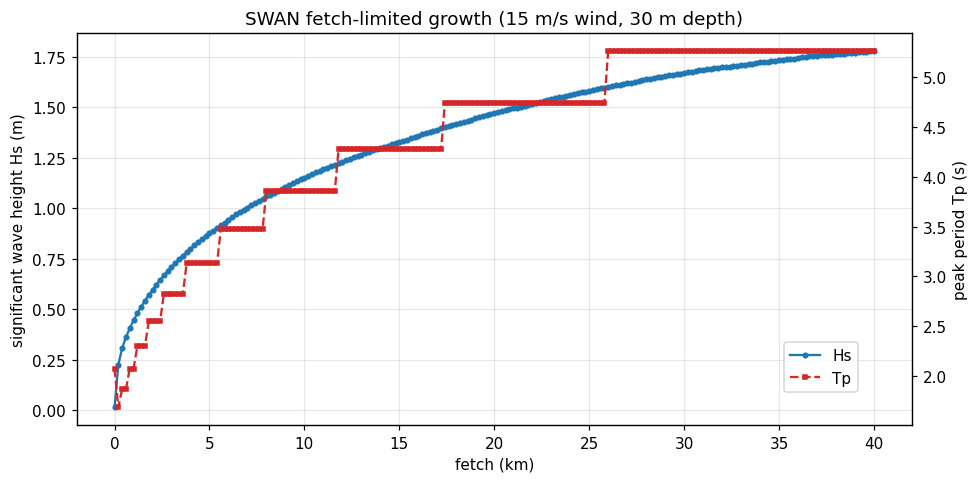

In [2]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(fetch.x_m / 1000, fetch.hs_m, "o-", color="C0", ms=3, label="Hs")
ax1.set(xlabel="fetch (km)", ylabel="significant wave height Hs (m)")
ax2 = ax1.twinx()
ax2.plot(fetch.x_m / 1000, fetch.tp_s, "s--", color="C3", ms=3, label="Tp")
ax2.set_ylabel("peak period Tp (s)")
ax1.set_title("SWAN fetch-limited growth (15 m/s wind, 30 m depth)")
ax1.grid(alpha=0.3)
fig.legend(loc="lower right", bbox_to_anchor=(0.88, 0.18)); plt.tight_layout()
print(f"Hs: {fetch.hs_m.iloc[0]:.2f} m (upwind) → {fetch.hs_m.iloc[-1]:.2f} m at "
      f"{fetch.x_m.iloc[-1]/1000:.0f} km;  Tp → {fetch.tp_s.iloc[-1]:.1f} s")

## 2 · The 2-D directional spectrum at 38 km

Read the native SWAN `SPEC2D` file and plot `E(f, θ)`. The energy sits in a tight
band of directions (a young wind sea aligned with the wind) and a single
frequency peak.

integrated from the spectrum: {'hs': 1.76, 'tp': 5.27, 'mean_dir_deg': 270.1}


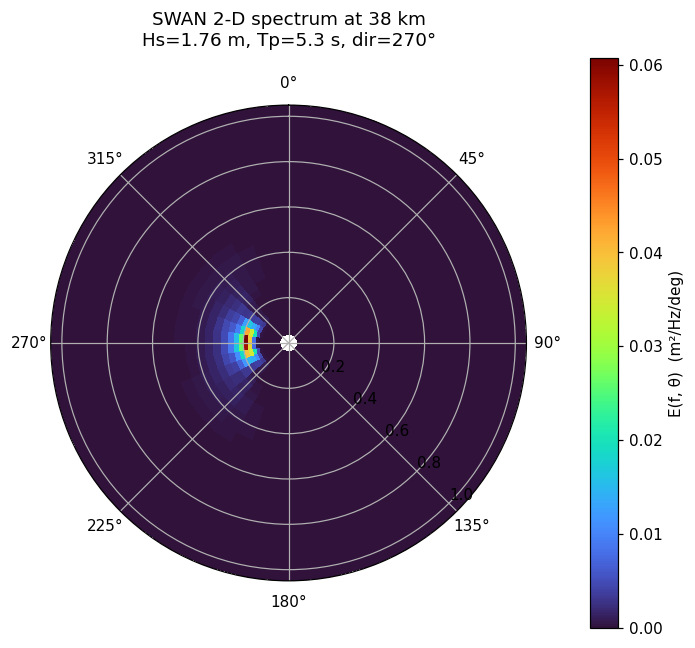

In [3]:
freq, theta, E2d, meta = readers.read_swan_spec(readers.swan_ideal_spec_path())
print("integrated from the spectrum:", {k: round(v, 2) for k, v in meta.items()})

fig = plt.figure(figsize=(6.5, 6))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
TH, FR = np.meshgrid(theta, freq)
pcm = ax.pcolormesh(TH, FR, E2d, cmap="turbo", shading="auto")
plt.colorbar(pcm, label="E(f, θ)  (m²/Hz/deg)", pad=0.1)
ax.set_title(f"SWAN 2-D spectrum at 38 km\nHs={meta['hs']:.2f} m, "
             f"Tp={meta['tp']:.1f} s, dir={meta['mean_dir_deg']:.0f}°", pad=20)
ax.set_rlabel_position(135); plt.tight_layout()

## 3 · Cross-check: spectrum vs SWAN's own bulk output

The Hs we integrate from the spectrum should match the `HSIGN` SWAN wrote to the
table at the same point — a good consistency test of the whole read/integrate
chain.

In [4]:
hs_table = float(fetch.iloc[(fetch.x_m - 38000).abs().idxmin()].hs_m)
print(f"Hs from spectrum integration : {meta['hs']:.2f} m")
print(f"Hs from SWAN table (HSIGN)   : {hs_table:.2f} m")
print(f"difference                   : {abs(meta['hs'] - hs_table):.3f} m")

Hs from spectrum integration : 1.76 m
Hs from SWAN table (HSIGN)   : 1.76 m
difference                   : 0.001 m


The two agree to a few cm — confirming the SWAN run and our spectral
post-processing are consistent.

---
### Reproduce / extend
- Build: `make config && make ser` (gfortran), then `./swan.exe` on the `INPUT`
  above. Vary `WIND`, depth, or fetch and watch the growth curve shift.
- The same `readers.read_swan_spec()` parses any SWAN `SPEC2D` file — point it at
  your nearshore run's output.
- For the synthetic-spectrum walkthrough (JONSWAP from scratch) see
  [`wave_spectra.ipynb`](wave_spectra.ipynb).